In [1]:
import os
import random
import warnings

import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [5]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

print(f"Image shape: {train_dataset[0][0].shape}")


Train samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


In [ ]:
SEED = 154
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Conv2d(64, 96, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(96),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d(1),
            torch.nn.Flatten(),
        )
        self.hidden = torch.nn.Sequential(
            torch.nn.Linear(96, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 3),
        )
        self.logits_layer = torch.nn.Linear(3, 10)

    def embedding(self, x):
        x = self.features(x)
        x = self.hidden(x)
        return x

    def forward(self, x):
        x = self.embedding(x)
        logits = self.logits_layer(x)
        return logits


model = SimpleCNN().to(device)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.02)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)
target_centers = torch.tensor([
    [-3.0, -3.0, -3.0],
    [-3.0,  3.0,  3.0],
    [ 3.0, -3.0,  3.0],
    [ 3.0,  3.0, -3.0],
    [-4.2,  0.0,  0.0],
    [ 4.2,  0.0,  0.0],
    [ 0.0, -4.2,  0.0],
    [ 0.0,  4.2,  0.0],
    [ 0.0,  0.0, -4.2],
    [ 0.0,  0.0,  4.2],
], dtype=torch.float32, device=device)

epochs = 10
center_loss_weight = 0.12

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        embeddings = model.embedding(images)
        logits = model.logits_layer(embeddings)
        class_loss = criterion(logits, labels)
        center_loss = torch.mean((embeddings - target_centers[labels]) ** 2)
        loss = class_loss + center_loss_weight * center_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f} - test acc: {acc:.2f}%")


Using device: cpu


KeyboardInterrupt: 

In [8]:
model_path = "kevton_nn_model.pt"

model.eval()

scripted_model = torch.jit.script(model.cpu())
scripted_model.save(model_path)

size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Saved model to {model_path}")
print(f"Model size: {size_mb:.2f} MB")

if size_mb > 5:
    raise ValueError("Model file is larger than the 5 MB limit.")


Saved model to kevton_nn_model.pt
Model size: 0.53 MB


In [28]:
import torch
import warnings
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

loaded_model = torch.jit.load(model_path, map_location=device)
loaded_model.eval()

embeddings_loaded_batches = []
labels_loaded_batches = []

with torch.no_grad():
    for images, labels in test_loader:
        x = images.to(device)
        emb = loaded_model.embedding(x)

        embeddings_loaded_batches.append(emb.cpu())
        labels_loaded_batches.append(labels.cpu())

Z_loaded = torch.cat(embeddings_loaded_batches, dim=0).numpy()
y_loaded = torch.cat(labels_loaded_batches, dim=0).numpy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmm = GaussianMixture(
        n_components=10,
        covariance_type="full",
        random_state=42,
        init_params="kmeans",
        n_init=3
    )
    gmm_labels = gmm.fit_predict(Z_loaded)

ari = adjusted_rand_score(y_loaded, gmm_labels)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Adjusted Rand Index (ARI): 0.6700


In [10]:
import plotly.express as px

class_names = test_dataset.classes if hasattr(test_dataset, "classes") else [str(i) for i in range(10)]
label_names = [class_names[i] for i in y_loaded]

fig = px.scatter_3d(
    x=Z_loaded[:, 0],
    y=Z_loaded[:, 1],
    z=Z_loaded[:, 2],
    color=label_names,
    opacity=0.7,
    labels={"x": "emb_1", "y": "emb_2", "z": "emb_3", "color": "class"},
    title="3D embedding point cloud (test set)"
)

fig.update_traces(marker=dict(size=2))
fig.show()


In [ ]:
# Grab a batch
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    emb = model.embedding(images)

print("Embedding shape:", emb.shape)

assert emb.shape[1] == 3, f"Expected embedding dim 3, got {emb.shape[1]}"
print("Embedding dimension is correct (3)")

Embedding shape: torch.Size([64, 3])
✅ Embedding dimension is correct (3)


In [ ]:
scripted_model = torch.jit.script(model.cpu())
scripted_model.save("kevton_nn_model.pt")

loaded_model = torch.jit.load("kevton_nn_model.pt")
loaded_model.eval()

images, _ = next(iter(test_loader))
with torch.no_grad():
    emb_loaded = loaded_model.embedding(images)

print("Loaded embedding shape:", emb_loaded.shape)
assert emb_loaded.shape[1] == 3
print(" Loaded model embedding works")

Loaded embedding shape: torch.Size([64, 3])
✅ Loaded model embedding works


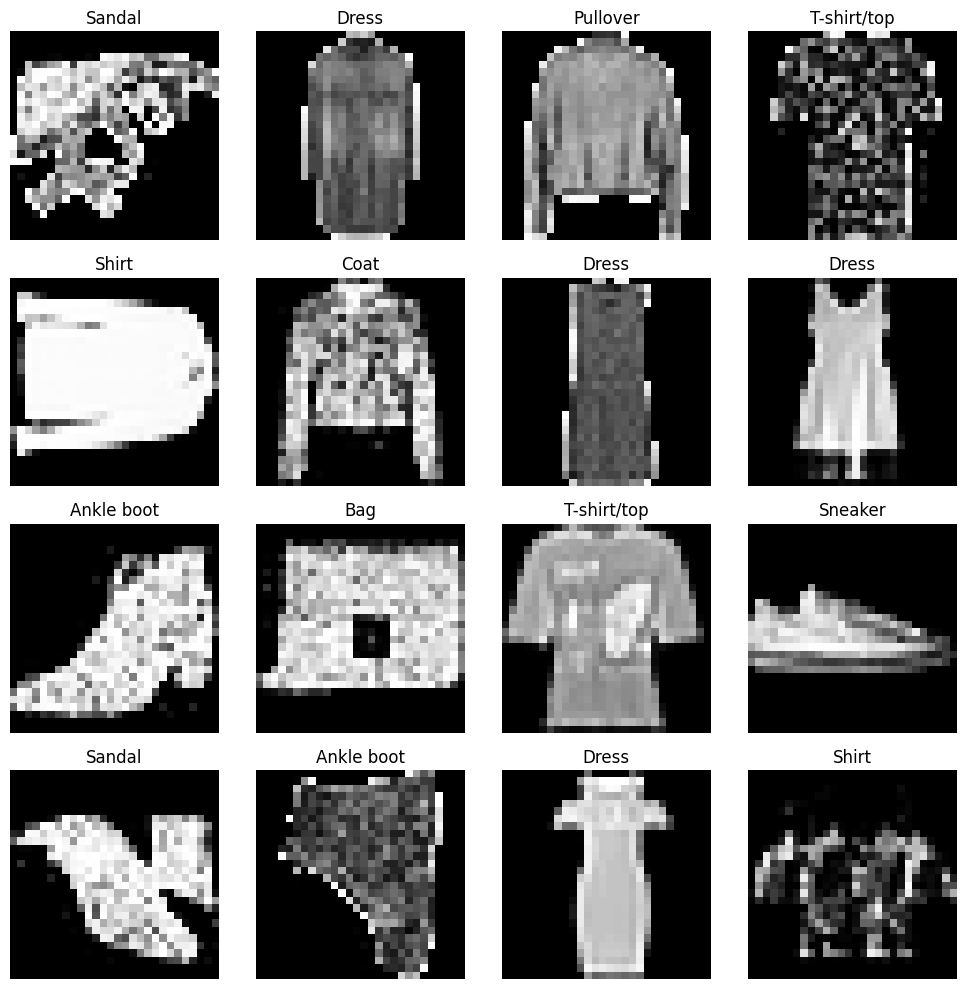

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch

data = torch.load("perturbed_train_compressed.pt")
images = data['images'].float() / 255.0
labels = data['labels']

# FashionMNIST class names
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Visualize a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
indices = np.random.choice(len(images), 16, replace=False)

for i, idx in enumerate(indices):
    ax = axes[i // 4, i % 4]
    img = images[idx].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels[idx].item()])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [23]:
aug_transform = transforms.Compose([
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=10,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
            shear=5,
        )
    ], p=0.5),
    transforms.ToTensor(),
])

aug_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=aug_transform,
)

aug_train_loader = DataLoader(aug_train_dataset, batch_size=64, shuffle=True)

aug_images, aug_labels = next(iter(aug_train_loader))
print("Augmented batch shape:", aug_images.shape)
print("Augmented batch dtype:", aug_images.dtype)


Augmented batch shape: torch.Size([64, 1, 28, 28])
Augmented batch dtype: torch.float32


In [14]:
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(device)

model = model.to(device)
x = x.to(device)

mps


In [34]:
SEED = 154
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Fine-tune the current model on the provided perturbed FashionMNIST data
from pathlib import Path
from torch.utils.data import TensorDataset

perturbed_path = Path("perturbed_train_compressed.pt")
if not perturbed_path.exists():
    raise FileNotFoundError("Could not find perturbed_train_compressed.pt")

perturbed_data = torch.load(perturbed_path, map_location="cpu")
perturbed_images = perturbed_data["images"].float()
if perturbed_data.get("is_uint8", False) or perturbed_images.max() > 1:
    perturbed_images = perturbed_images / 255.0
perturbed_labels = perturbed_data["labels"].long()

perturbed_dataset = TensorDataset(perturbed_images, perturbed_labels)
perturbed_loader = DataLoader(perturbed_dataset, batch_size=64, shuffle=True)

robust_eval_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=20,
        translate=(0.10, 0.10),
        scale=(0.90, 1.10),
        shear=10,
    ),
    transforms.ToTensor(),
])

robust_test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=robust_eval_transform,
)
robust_test_loader = DataLoader(robust_test_dataset, batch_size=64, shuffle=False)

model = model.to(device)
finetune_criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.02)
finetune_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

finetune_epochs = 2
finetune_center_weight = 0.03

def compute_logits_and_center_loss(current_model, embeddings, labels):
    zero = torch.tensor(0.0, device=embeddings.device)
    if hasattr(current_model, "logits_from_embedding") and hasattr(current_model, "class_centers"):
        logits = current_model.logits_from_embedding(embeddings)
        center_loss = torch.mean((embeddings - current_model.class_centers[labels]) ** 2)
        return logits, center_loss
    logits = current_model.logits_layer(embeddings)
    if "target_centers" in globals():
        center_loss = torch.mean((embeddings - target_centers[labels]) ** 2)
        return logits, center_loss
    return logits, zero

def evaluate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            embeddings = model.embedding(images)
            logits, _ = compute_logits_and_center_loss(model, embeddings, labels)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

best_state = None
best_robust_acc = -1.0

for epoch in range(finetune_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in perturbed_loader:
        images, labels = images.to(device), labels.to(device)

        finetune_optimizer.zero_grad()
        embeddings = model.embedding(images)
        logits, center_loss = compute_logits_and_center_loss(model, embeddings, labels)
        class_loss = finetune_criterion(logits, labels)
        loss = class_loss + finetune_center_weight * center_loss

        loss.backward()
        finetune_optimizer.step()
        running_loss += loss.item()

    clean_acc = evaluate_accuracy(test_loader)
    robust_acc = evaluate_accuracy(robust_test_loader)
    avg_loss = running_loss / len(perturbed_loader)

    print(
        f"[finetune] Epoch {epoch+1}/{finetune_epochs} - "
        f"loss: {avg_loss:.4f} - clean acc: {clean_acc:.2f}% - "
        f"perturbed acc: {robust_acc:.2f}%"
    )

    if robust_acc > best_robust_acc:
        best_robust_acc = robust_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"Restored best fine-tuned checkpoint with perturbed acc: {best_robust_acc:.2f}%")

images, _ = next(iter(test_loader))
with torch.no_grad():
    finetuned_emb = model.embedding(images.to(device))

print("Fine-tuned embedding shape:", finetuned_emb.shape)
assert finetuned_emb.shape[1] == 3


Using device: cpu
[finetune] Epoch 1/2 - loss: 0.6411 - clean acc: 86.70% - perturbed acc: 60.98%
[finetune] Epoch 2/2 - loss: 0.6256 - clean acc: 87.53% - perturbed acc: 60.26%
Restored best fine-tuned checkpoint with perturbed acc: 60.98%
Fine-tuned embedding shape: torch.Size([64, 3])


In [38]:
# Mixed clean + perturbed refinement for the stronger original model
from pathlib import Path
from torch.utils.data import TensorDataset

SEED = 154
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Load provided perturbed training set
perturbed_path = Path("perturbed_train_compressed.pt")
if not perturbed_path.exists():
    raise FileNotFoundError("Could not find perturbed_train_compressed.pt")

perturbed_data = torch.load(perturbed_path, map_location="cpu")
perturbed_images = perturbed_data["images"].float()
if perturbed_data.get("is_uint8", False) or perturbed_images.max() > 1:
    perturbed_images = perturbed_images / 255.0
perturbed_labels = perturbed_data["labels"].long()

perturbed_dataset = TensorDataset(perturbed_images, perturbed_labels)
perturbed_loader = DataLoader(perturbed_dataset, batch_size=64, shuffle=True)

# Build a fixed perturbed validation set from FashionMNIST test data
fixed_perturb_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=20,
        translate=(0.10, 0.10),
        scale=(0.90, 1.10),
        shear=10,
    ),
    transforms.ToTensor(),
])

robust_val_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=fixed_perturb_transform,
)
robust_val_loader = DataLoader(robust_val_dataset, batch_size=64, shuffle=False)

mix_criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.02)
mix_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

mix_epochs = 2
mix_center_weight = 0.04

def compute_logits_and_center_loss(current_model, embeddings, labels):
    zero = torch.tensor(0.0, device=embeddings.device)
    if hasattr(current_model, "logits_from_embedding") and hasattr(current_model, "class_centers"):
        logits = current_model.logits_from_embedding(embeddings)
        center_loss = torch.mean((embeddings - current_model.class_centers[labels]) ** 2)
        return logits, center_loss
    logits = current_model.logits_layer(embeddings)
    if "target_centers" in globals():
        center_loss = torch.mean((embeddings - target_centers[labels]) ** 2)
        return logits, center_loss
    return logits, zero

def evaluate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            embeddings = model.embedding(images)
            logits, _ = compute_logits_and_center_loss(model, embeddings, labels)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def evaluate_ari(loader):
    model.eval()
    embedding_batches = []
    label_batches = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            emb = model.embedding(images)
            embedding_batches.append(emb.cpu())
            label_batches.append(labels.cpu())

    Z = torch.cat(embedding_batches, dim=0).numpy()
    y = torch.cat(label_batches, dim=0).numpy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gmm = GaussianMixture(
            n_components=10,
            covariance_type="full",
            random_state=42,
            init_params="kmeans",
            n_init=3,
        )
        pred = gmm.fit_predict(Z)

    return adjusted_rand_score(y, pred)

best_state = None
best_robust_ari = -1.0

for epoch in range(mix_epochs):
    model.train()
    running_loss = 0.0

    clean_iter = iter(train_loader)
    perturbed_iter = iter(perturbed_loader)
    num_steps = max(len(train_loader), len(perturbed_loader))

    for step in range(num_steps):
        # Alternate clean and perturbed batches
        if step % 2 == 0:
            try:
                images, labels = next(clean_iter)
            except StopIteration:
                clean_iter = iter(train_loader)
                images, labels = next(clean_iter)
        else:
            try:
                images, labels = next(perturbed_iter)
            except StopIteration:
                perturbed_iter = iter(perturbed_loader)
                images, labels = next(perturbed_iter)

        images, labels = images.to(device), labels.to(device)

        mix_optimizer.zero_grad()
        embeddings = model.embedding(images)
        logits, center_loss = compute_logits_and_center_loss(model, embeddings, labels)
        class_loss = mix_criterion(logits, labels)
        loss = class_loss + mix_center_weight * center_loss

        loss.backward()
        mix_optimizer.step()
        running_loss += loss.item()

    clean_acc = evaluate_accuracy(test_loader)
    robust_acc = evaluate_accuracy(robust_val_loader)
    robust_ari = evaluate_ari(robust_val_loader)
    avg_loss = running_loss / num_steps

    print(
        f"[mixed refine] Epoch {epoch+1}/{mix_epochs} - "
        f"loss: {avg_loss:.4f} - clean acc: {clean_acc:.2f}% - "
        f"perturbed acc: {robust_acc:.2f}% - perturbed ARI: {robust_ari:.4f}"
    )

    if robust_ari > best_robust_ari:
        best_robust_ari = robust_ari
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"Restored best checkpoint with perturbed ARI: {best_robust_ari:.4f}")

images, _ = next(iter(test_loader))
with torch.no_grad():
    mixed_emb = model.embedding(images.to(device))

print("Mixed-refined embedding shape:", mixed_emb.shape)
assert mixed_emb.shape[1] == 3


[mixed refine] Epoch 1/2 - loss: 0.6307 - clean acc: 88.44% - perturbed acc: 63.49% - perturbed ARI: 0.3598
[mixed refine] Epoch 2/2 - loss: 0.6202 - clean acc: 88.91% - perturbed acc: 62.35% - perturbed ARI: 0.3102
Restored best checkpoint with perturbed ARI: 0.3598
Mixed-refined embedding shape: torch.Size([64, 3])


In [ ]:
# Strong robust model with center-based 3D head + mixed clean/perturbed training + invariance loss
from pathlib import Path
from torch.utils.data import TensorDataset

SEED = 154
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

perturbed_path = Path("perturbed_train_compressed.pt")
if not perturbed_path.exists():
    raise FileNotFoundError("Could not find perturbed_train_compressed.pt")

perturbed_data = torch.load(perturbed_path, map_location="cpu")
perturbed_images = perturbed_data["images"].float()
if perturbed_data.get("is_uint8", False) or perturbed_images.max() > 1:
    perturbed_images = perturbed_images / 255.0
perturbed_labels = perturbed_data["labels"].long()

# Fixed 50k / 10k split
perm = torch.randperm(len(perturbed_images), generator=torch.Generator().manual_seed(SEED))
val_size = 10000
val_idx = perm[:val_size]
train_idx = perm[val_size:]

perturbed_train_images = perturbed_images[train_idx]
perturbed_train_labels = perturbed_labels[train_idx]
perturbed_val_images = perturbed_images[val_idx]
perturbed_val_labels = perturbed_labels[val_idx]

perturbed_train_dataset = TensorDataset(perturbed_train_images, perturbed_train_labels)
perturbed_val_dataset = TensorDataset(perturbed_val_images, perturbed_val_labels)

batch_size = 128
clean_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
perturbed_train_loader = DataLoader(perturbed_train_dataset, batch_size=batch_size, shuffle=True)
perturbed_val_loader = DataLoader(perturbed_val_dataset, batch_size=256, shuffle=False)

# Mild augmentation for invariance training
invariance_transform = transforms.RandomAffine(
    degrees=12,
    translate=(0.06, 0.06),
    scale=(0.95, 1.05),
    shear=6,
)

def augment_batch_tensor(x):
    # x is [B, 1, 28, 28] on CPU or GPU, values in [0,1]
    out = []
    for img in x.cpu():
        out.append(invariance_transform(img))
    return torch.stack(out, dim=0).to(x.device)

class NewCenterCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),

            torch.nn.Conv2d(64, 96, kernel_size=3, padding=1, bias=False),
            torch.nn.BatchNorm2d(96),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d(1),
            torch.nn.Flatten(),
        )

        self.projection = torch.nn.Sequential(
            torch.nn.Linear(96, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 3),
        )

        centers = torch.tensor([
            [-3.0, -3.0, -3.0],
            [-3.0,  3.0,  3.0],
            [ 3.0, -3.0,  3.0],
            [ 3.0,  3.0, -3.0],
            [-4.2,  0.0,  0.0],
            [ 4.2,  0.0,  0.0],
            [ 0.0, -4.2,  0.0],
            [ 0.0,  4.2,  0.0],
            [ 0.0,  0.0, -4.2],
            [ 0.0,  0.0,  4.2],
        ], dtype=torch.float32)
        self.register_buffer("class_centers", centers)

    def embedding(self, x):
        x = self.features(x)
        return self.projection(x)

    def logits_from_embedding(self, z):
        diff = z[:, None, :] - self.class_centers[None, :, :]
        return -torch.sum(diff * diff, dim=2)

    def forward(self, x):
        z = self.embedding(x)
        return self.logits_from_embedding(z)

model = NewCenterCNN().to(device)

criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.02)
optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=6)

epochs = 6
center_weight = 0.08
invariance_weight = 0.12

def evaluate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def evaluate_ari(loader):
    model.eval()
    embedding_batches = []
    label_batches = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            emb = model.embedding(images)
            embedding_batches.append(emb.cpu())
            label_batches.append(labels.cpu())

    Z = torch.cat(embedding_batches, dim=0).numpy()
    y = torch.cat(label_batches, dim=0).numpy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gmm = GaussianMixture(
            n_components=10,
            covariance_type="full",
            random_state=42,
            init_params="kmeans",
            n_init=3,
        )
        pred = gmm.fit_predict(Z)

    return adjusted_rand_score(y, pred)

best_state = None
best_perturbed_ari = -1.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    clean_iter = iter(clean_train_loader)
    pert_iter = iter(perturbed_train_loader)
    steps = max(len(clean_train_loader), len(perturbed_train_loader))

    for _ in range(steps):
        # one clean batch
        try:
            clean_images, clean_labels = next(clean_iter)
        except StopIteration:
            clean_iter = iter(clean_train_loader)
            clean_images, clean_labels = next(clean_iter)

        clean_images = clean_images.to(device)
        clean_labels = clean_labels.to(device)
        clean_aug = augment_batch_tensor(clean_images)

        optimizer.zero_grad()

        z_clean = model.embedding(clean_images)
        z_clean_aug = model.embedding(clean_aug)

        logits_clean = model.logits_from_embedding(z_clean)
        logits_clean_aug = model.logits_from_embedding(z_clean_aug)

        ce_clean = criterion(logits_clean, clean_labels)
        ce_clean_aug = criterion(logits_clean_aug, clean_labels)
        center_clean = torch.mean((z_clean - model.class_centers[clean_labels]) ** 2)
        inv_clean = torch.mean((z_clean - z_clean_aug) ** 2)

        clean_loss = ce_clean + ce_clean_aug + center_weight * center_clean + invariance_weight * inv_clean
        clean_loss.backward()
        optimizer.step()
        running_loss += clean_loss.item()

        # one perturbed batch
        try:
            pert_images, pert_labels = next(pert_iter)
        except StopIteration:
            pert_iter = iter(perturbed_train_loader)
            pert_images, pert_labels = next(pert_iter)

        pert_images = pert_images.to(device)
        pert_labels = pert_labels.to(device)

        optimizer.zero_grad()

        z_pert = model.embedding(pert_images)
        logits_pert = model.logits_from_embedding(z_pert)

        ce_pert = criterion(logits_pert, pert_labels)
        center_pert = torch.mean((z_pert - model.class_centers[pert_labels]) ** 2)

        pert_loss = ce_pert + center_weight * center_pert
        pert_loss.backward()
        optimizer.step()
        running_loss += pert_loss.item()

    scheduler.step()

    clean_acc = evaluate_accuracy(test_loader)
    pert_acc = evaluate_accuracy(perturbed_val_loader)
    pert_ari = evaluate_ari(perturbed_val_loader)
    avg_loss = running_loss / (steps * 2)

    print(
        f"[robust center] Epoch {epoch+1}/{epochs} - "
        f"loss: {avg_loss:.4f} - clean acc: {clean_acc:.2f}% - "
        f"perturbed acc: {pert_acc:.2f}% - perturbed ARI: {pert_ari:.4f}"
    )

    if pert_ari > best_perturbed_ari:
        best_perturbed_ari = pert_ari
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"Restored best checkpoint with perturbed ARI: {best_perturbed_ari:.4f}")

model.eval()
with torch.no_grad():
    sample_emb = model.embedding(next(iter(test_loader))[0].to(device))

print("Robust center embedding shape:", sample_emb.shape)
assert sample_emb.shape[1] == 3

robust_center_model_path = "kevton_nn_model_1.pt"
scripted_model = torch.jit.script(model.cpu())
scripted_model.save(robust_center_model_path)

print("Saved robust center model to", robust_center_model_path)
print("Robust center model size (MB):", os.path.getsize(robust_center_model_path) / (1024 * 1024))


Using device: cpu
[robust center] Epoch 1/6 - loss: 4.1080 - clean acc: 76.53% - perturbed acc: 51.55% - perturbed ARI: 0.3261
[robust center] Epoch 2/6 - loss: 3.0135 - clean acc: 81.28% - perturbed acc: 66.12% - perturbed ARI: 0.4325
[robust center] Epoch 3/6 - loss: 2.6837 - clean acc: 82.54% - perturbed acc: 68.41% - perturbed ARI: 0.4956
[robust center] Epoch 4/6 - loss: 2.4730 - clean acc: 85.84% - perturbed acc: 72.04% - perturbed ARI: 0.5263
[robust center] Epoch 5/6 - loss: 2.2856 - clean acc: 86.96% - perturbed acc: 74.40% - perturbed ARI: 0.5380
[robust center] Epoch 6/6 - loss: 2.1518 - clean acc: 87.66% - perturbed acc: 74.89% - perturbed ARI: 0.5492
Restored best checkpoint with perturbed ARI: 0.5492
Robust center embedding shape: torch.Size([64, 3])
Saved robust center model to robust_center_nn_model.pt
Robust center model size (MB): 0.5277214050292969
